# 37. The Equipment Selection Problem (RTG vs. RMG vs. Straddle)
## Tier 3: Artificial Bee Colony Optimization Metaheuristic

### Goal
Implement an Artificial Bee Colony (ABC) algorithm to solve large-scale equipment selection problems by mimicking the intelligent foraging behavior of honeybee swarms, achieving superior performance through population-based metaheuristic optimization.

### Key Assumptions
- Equipment selection can be represented as a continuous optimization problem
- Multiple conflicting objectives can be combined into a single fitness function
- Swarm intelligence can find near-optimal solutions through collective behavior
- Solution space is too large for exhaustive search but has exploitable structure

### Approach (Step-by-Step)
1. **Solution Encoding**: Represent equipment configurations as continuous vectors with real-valued parameters
2. **Population Initialization**: Generate diverse initial solutions covering the solution space
3. **Employed Bee Phase**: Each bee explores neighborhood of its current solution
4. **Onlooker Bee Phase**: Bees probabilistically select solutions based on fitness (roulette wheel)
5. **Scout Bee Phase**: Abandoned solutions are replaced with random exploration
6. **Convergence Tracking**: Monitor fitness improvement and algorithm convergence

### What to Look for in the Results
- Convergence curves showing fitness improvement over iterations
- Solution diversity metrics and exploration-exploitation balance
- Comparison with greedy and mathematical optimization baselines
- Sensitivity analysis of algorithm parameters (colony size, abandonment limit)

### Concrete Example
Mediterranean Container Terminal optimization:
- Colony size: 40 bees (20 employed, 20 onlooker)
- Maximum iterations: 500 with convergence monitoring
- Solution space: RTG (0-25), RMG (0-18), Straddle (0-40) units
- Multi-objective fitness: cost (30%), productivity (40%), flexibility (20%), sustainability (10%)

### Why this Tier Exists vs. Previous Tiers
**Artificial Bee Colony provides:**
- **Scalability**: Handles much larger problem instances than exact methods
- **Global Optimization**: Avoids local optima through swarm intelligence and exploration
- **Multi-Objective Handling**: Naturally balances multiple conflicting objectives
- **Robustness**: Performs well even with imperfect or noisy fitness evaluations

**Advantages over Mathematical Optimization (Tier 1):**
- Scales to problems with hundreds of variables and constraints
- Handles non-linear, non-convex objective functions
- Provides good solutions quickly for time-critical decisions

**Advantages over Constraint Propagation (Tier 2):**
- Better performance on large-scale problems
- Handles continuous optimization naturally
- More robust to noisy or incomplete constraint information

**When to Use This Tier:**
- Large-scale equipment selection problems
- When approximate solutions are acceptable
- Problems with complex, non-linear relationships
- Time-critical decision making scenarios

**Limitations:**
- No guarantee of optimality
- Requires parameter tuning for best performance
- May converge to local optima in complex landscapes
- Computational cost grows with colony size and iterations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import random
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

print('Equipment Selection - Artificial Bee Colony Optimization')
print('Swarm Intelligence Metaheuristic')

Equipment Selection - Artificial Bee Colony Optimization
Swarm Intelligence Metaheuristic


### Equipment Data Structure

In [2]:
@dataclass
class EquipmentType:
    name: str
    capital_cost: float  # Million USD
    operating_cost: float  # Million USD/year
    productivity: float  # Containers/hour
    flexibility: float  # 0-1 scale
    maintenance: float  # Million USD/year
    footprint: float  # Square meters
    energy_consumption: float  # kWh/container
    
# Define equipment types
equipment_types = {
    'RTG': EquipmentType(
        name='Rubber-Tired Gantry',
        capital_cost=2.5,
        operating_cost=0.8,
        productivity=25,
        flexibility=0.8,
        maintenance=0.3,
        footprint=200,
        energy_consumption=3.2
    ),
    'RMG': EquipmentType(
        name='Rail-Mounted Gantry',
        capital_cost=3.2,
        operating_cost=0.6,
        productivity=35,
        flexibility=0.4,
        maintenance=0.25,
        footprint=150,
        energy_consumption=2.8
    ),
    'Straddle': EquipmentType(
        name='Straddle Carrier',
        capital_cost=4.1,
        operating_cost=1.1,
        productivity=20,
        flexibility=0.9,
        maintenance=0.4,
        footprint=100,
        energy_consumption=4.5
    )
}

print('Equipment Types Defined:')
for eq_type, eq_data in equipment_types.items():
    print(f'{eq_type}: {eq_data.name}')
    print(f'  Capital Cost: ${eq_data.capital_cost}M')
    print(f'  Operating Cost: ${eq_data.operating_cost}M/year')
    print(f'  Productivity: {eq_data.productivity} containers/hour')
    print(f'  Flexibility: {eq_data.flexibility:.1f}')
    print()

Equipment Types Defined:
RTG: Rubber-Tired Gantry
  Capital Cost: $2.5M
  Operating Cost: $0.8M/year
  Productivity: 25 containers/hour
  Flexibility: 0.8

RMG: Rail-Mounted Gantry
  Capital Cost: $3.2M
  Operating Cost: $0.6M/year
  Productivity: 35 containers/hour
  Flexibility: 0.4

Straddle: Straddle Carrier
  Capital Cost: $4.1M
  Operating Cost: $1.1M/year
  Productivity: 20 containers/hour
  Flexibility: 0.9



### Artificial Bee Colony Algorithm Implementation

In [3]:
@dataclass
class ABCConfig:
    colony_size: int = 40
    max_iterations: int = 500
    abandonment_limit: int = 50
    convergence_window: int = 20
    
@dataclass
class BeeSolution:
    position: np.ndarray  # [RTG, RMG, Straddle]
    fitness: float
    trial_count: int = 0
    
class ArtificialBeeColonyOptimizer:
    def __init__(self, equipment_types: Dict[str, EquipmentType], 
                 config: ABCConfig,
                 budget_limit: float = 50.0,
                 min_productivity: float = 500,
                 objective_weights: Optional[Dict[str, float]] = None):
        
        self.equipment_types = equipment_types
        self.config = config
        self.budget_limit = budget_limit
        self.min_productivity = min_productivity
        
        # Default objective weights
        self.objective_weights = objective_weights or {
            'cost': 0.3,
            'productivity': 0.4,
            'flexibility': 0.2,
            'sustainability': 0.1
        }
        
        # Solution bounds for each equipment type
        self.bounds = {
            'RTG': (0, 25),
            'RMG': (0, 18),
            'Straddle': (0, 40)
        }
        
        # Initialize colony
        self.employed_bees = []
        self.onlooker_bees = []
        self.best_solution = None
        self.best_fitness = -np.inf
        
        # Tracking
        self.fitness_history = []
        self.diversity_history = []
        self.convergence_iteration = None
        
    def evaluate_fitness(self, position: np.ndarray) -> float:
        """Evaluate fitness of a solution position"""
        # Convert to integer equipment counts
        rtg = max(0, int(position[0]))
        rmg = max(0, int(position[1]))
        straddle = max(0, int(position[2]))
        
        # Calculate objectives
        total_cost = (self.equipment_types['RTG'].capital_cost * rtg +
                      self.equipment_types['RMG'].capital_cost * rmg +
                      self.equipment_types['Straddle'].capital_cost * straddle)
        
        total_productivity = (self.equipment_types['RTG'].productivity * rtg +
                               self.equipment_types['RMG'].productivity * rmg +
                               self.equipment_types['Straddle'].productivity * straddle)
        
        total_units = rtg + rmg + straddle
        
        if total_units == 0:
            return -1e6  # Very bad fitness
        
        # Flexibility (weighted average)
        weighted_flexibility = (self.equipment_types['RTG'].flexibility * rtg +
                                self.equipment_types['RMG'].flexibility * rmg +
                                self.equipment_types['Straddle'].flexibility * straddle) / total_units
        
        # Sustainability (inverse energy consumption)
        total_energy = (self.equipment_types['RTG'].energy_consumption * rtg +
                        self.equipment_types['RMG'].energy_consumption * rmg +
                        self.equipment_types['Straddle'].energy_consumption * straddle)
        
        avg_energy = total_energy / total_units if total_units > 0 else 1e6
        sustainability_score = 1.0 / (1.0 + avg_energy)  # Higher is better
        
        # Check constraints (penalty approach)
        penalty = 0
        if total_cost > self.budget_limit:
            penalty += (total_cost - self.budget_limit) * 10
        if total_productivity < self.min_productivity:
            penalty += (self.min_productivity - total_productivity) * 5
        if total_units < 5:
            penalty += (5 - total_units) * 2
        
        # Calculate weighted fitness (higher is better)
        fitness = (
            self.objective_weights['cost'] * (1.0 / (1.0 + total_cost)) +
            self.objective_weights['productivity'] * (total_productivity / 1000.0) +
            self.objective_weights['flexibility'] * weighted_flexibility +
            self.objective_weights['sustainability'] * sustainability_score
        ) - penalty
        
        return fitness
    
    def initialize_population(self):
        """Initialize the bee colony with random solutions"""
        self.employed_bees = []
        
        for i in range(self.config.colony_size // 2):
            # Random position within bounds
            position = np.array([
                np.random.uniform(self.bounds['RTG'][0], self.bounds['RTG'][1]),
                np.random.uniform(self.bounds['RMG'][0], self.bounds['RMG'][1]),
                np.random.uniform(self.bounds['Straddle'][0], self.bounds['Straddle'][1])
            ])
            
            fitness = self.evaluate_fitness(position)
            
            bee = BeeSolution(position=position, fitness=fitness)
            self.employed_bees.append(bee)
            
            # Update best solution
            if fitness > self.best_fitness:
                self.best_fitness = fitness
                self.best_solution = position.copy()
        
        # Initialize onlooker bees (they will copy employed bees initially)
        self.onlooker_bees = []
        for i in range(self.config.colony_size // 2):
            bee = BeeSolution(position=self.employed_bees[i].position.copy(),
                           fitness=self.employed_bees[i].fitness)
            self.onlooker_bees.append(bee)
    
    def employed_bee_phase(self):
        """Employed bees explore neighborhood of their food sources"""
        for i, bee in enumerate(self.employed_bees):
            # Generate new solution by modifying one parameter
            new_position = bee.position.copy()
            param_to_modify = np.random.randint(0, 3)
            
            # Apply random modification
            bounds_list = [self.bounds['RTG'], self.bounds['RMG'], self.bounds['Straddle']]
            bounds = bounds_list[param_to_modify]
            
            # Gaussian perturbation
            modification = np.random.normal(0, (bounds[1] - bounds[0]) * 0.1)
            new_position[param_to_modify] += modification
            
            # Ensure within bounds
            new_position[param_to_modify] = np.clip(new_position[param_to_modify], bounds[0], bounds[1])
            
            new_fitness = self.evaluate_fitness(new_position)
            
            # Greedy selection
            if new_fitness > bee.fitness:
                bee.position = new_position
                bee.fitness = new_fitness
                bee.trial_count = 0
                
                # Update best solution
                if new_fitness > self.best_fitness:
                    self.best_fitness = new_fitness
                    self.best_solution = new_position.copy()
            else:
                bee.trial_count += 1
    
    def onlooker_bee_phase(self):
        """Onlooker bees choose food sources based on fitness probabilities"""
        # Calculate selection probabilities
        fitness_values = [bee.fitness for bee in self.employed_bees]
        
        # Handle negative fitness values
        min_fitness = min(fitness_values)
        if min_fitness < 0:
            fitness_values = [f - min_fitness + 1e-6 for f in fitness_values]
        
        total_fitness = sum(fitness_values)
        
        if total_fitness > 0:
            probabilities = [f / total_fitness for f in fitness_values]
        else:
            probabilities = [1.0 / len(fitness_values)] * len(fitness_values)
        
        # Each onlooker bee chooses a source
        for bee in self.onlooker_bees:
            # Roulette wheel selection
            selected_idx = np.random.choice(len(self.employed_bees), p=probabilities)
            selected_bee = self.employed_bees[selected_idx]
            
            # Generate new solution near selected source
            new_position = selected_bee.position.copy()
            param_to_modify = np.random.randint(0, 3)
            
            bounds_list = [self.bounds['RTG'], self.bounds['RMG'], self.bounds['Straddle']]
            bounds = bounds_list[param_to_modify]
            
            modification = np.random.normal(0, (bounds[1] - bounds[0]) * 0.1)
            new_position[param_to_modify] += modification
            new_position[param_to_modify] = np.clip(new_position[param_to_modify], bounds[0], bounds[1])
            
            new_fitness = self.evaluate_fitness(new_position)
            
            # Greedy selection
            if new_fitness > bee.fitness:
                bee.position = new_position
                bee.fitness = new_fitness
                bee.trial_count = 0
                
                # Update best solution
                if new_fitness > self.best_fitness:
                    self.best_fitness = new_fitness
                    self.best_solution = new_position.copy()
            else:
                bee.trial_count += 1
    
    def scout_bee_phase(self):
        """Scout bees replace abandoned sources with random solutions"""
        for i, bee in enumerate(self.employed_bees):
            if bee.trial_count > self.config.abandonment_limit:
                # Replace with random solution
                bee.position = np.array([
                    np.random.uniform(self.bounds['RTG'][0], self.bounds['RTG'][1]),
                    np.random.uniform(self.bounds['RMG'][0], self.bounds['RMG'][1]),
                    np.random.uniform(self.bounds['Straddle'][0], self.bounds['Straddle'][1])
                ])
                
                bee.fitness = self.evaluate_fitness(bee.position)
                bee.trial_count = 0
                
                # Update best solution
                if bee.fitness > self.best_fitness:
                    self.best_fitness = bee.fitness
                    self.best_solution = bee.position.copy()
    
    def calculate_diversity(self) -> float:
        """Calculate population diversity"""
        all_positions = [bee.position for bee in self.employed_bees + self.onlooker_bees]
        
        if len(all_positions) < 2:
            return 0.0
        
        positions_array = np.array(all_positions)
        mean_position = np.mean(positions_array, axis=0)
        
        diversity = np.mean([np.linalg.norm(pos - mean_position) for pos in positions_array])
        return diversity
    
    def check_convergence(self) -> bool:
        """Check if algorithm has converged"""
        if len(self.fitness_history) < self.config.convergence_window:
            return False
        
        recent_fitness = self.fitness_history[-self.config.convergence_window:]
        fitness_improvement = max(recent_fitness) - min(recent_fitness)
        
        return fitness_improvement < 1e-6
    
    def optimize(self) -> Tuple[np.ndarray, List[float], List[float]]:
        """Run the ABC optimization algorithm"""
        print(f'Starting ABC optimization with {self.config.colony_size} bees...')
        print(f'Employed bees: {len(self.employed_bees) if self.employed_bees else self.config.colony_size // 2}')
        print(f'Onlooker bees: {len(self.onlooker_bees) if self.onlooker_bees else self.config.colony_size // 2}')
        print(f'Maximum iterations: {self.config.max_iterations}')
        
        # Initialize population
        self.initialize_population()
        print(f'Initial population created. Best fitness: {self.best_fitness:.4f}')
        
        start_time = time.time()
        
        for iteration in range(self.config.max_iterations):
            # Employed bee phase
            self.employed_bee_phase()
            
            # Onlooker bee phase
            self.onlooker_bee_phase()
            
            # Scout bee phase
            self.scout_bee_phase()
            
            # Record metrics
            self.fitness_history.append(self.best_fitness)
            self.diversity_history.append(self.calculate_diversity())
            
            # Progress reporting
            if (iteration + 1) % 50 == 0:
                print(f"Iteration {iteration + 1}: Best fitness = {self.best_fitness:.4f}, "
                      f"Diversity = {self.diversity_history[-1]:.3f}")
            
            # Check convergence
            if iteration > 100 and self.check_convergence():
                print(f"Convergence detected at iteration {iteration + 1}")
                self.convergence_iteration = iteration + 1
                break
        
        end_time = time.time()
        print(f'\nOptimization completed in {end_time - start_time:.2f} seconds')
        print(f'Final best fitness: {self.best_fitness:.4f}')
        
        return self.best_solution, self.fitness_history, self.diversity_history

print('Artificial Bee Colony Algorithm Implementation Complete')

Artificial Bee Colony Algorithm Implementation Complete


### Run ABC Optimization

In [4]:
# Configure ABC optimizer
config = ABCConfig(
    colony_size=40,
    max_iterations=500,
    abandonment_limit=50,
    convergence_window=20
)

# Create optimizer
optimizer = ArtificialBeeColonyOptimizer(
    equipment_types=equipment_types,
    config=config,
    budget_limit=50.0,
    min_productivity=500
)

# Run optimization
best_solution, fitness_history, diversity_history = optimizer.optimize()

# Convert best solution to integer quantities for display
best_rtg = max(0, int(best_solution[0]))
best_rmg = max(0, int(best_solution[1]))
best_straddle = max(0, int(best_solution[2]))

print("\n=== OPTIMAL SOLUTION DETAILS ===")
print(f"RTG units: {best_rtg}")
print(f"RMG units: {best_rmg}")
print(f"Straddle units: {best_straddle}")
print(f"Total equipment: {best_rtg + best_rmg + best_straddle}")

# Calculate solution metrics
total_cost = (best_rtg * equipment_types['RTG'].capital_cost +
               best_rmg * equipment_types['RMG'].capital_cost +
               best_straddle * equipment_types['Straddle'].capital_cost)

total_productivity = (best_rtg * equipment_types['RTG'].productivity +
                       best_rmg * equipment_types['RMG'].productivity +
                       best_straddle * equipment_types['Straddle'].productivity)

total_units = best_rtg + best_rmg + best_straddle
weighted_flexibility = (equipment_types['RTG'].flexibility * best_rtg +
                        equipment_types['RMG'].flexibility * best_rmg +
                        equipment_types['Straddle'].flexibility * best_straddle) / total_units

total_energy = (best_rtg * equipment_types['RTG'].energy_consumption +
                 best_rmg * equipment_types['RMG'].energy_consumption +
                 best_straddle * equipment_types['Straddle'].energy_consumption)

avg_energy = total_energy / total_units if total_units > 0 else 0

print(f"\nTotal cost: ${total_cost:.1f}M")
print(f"Total productivity: {total_productivity:.0f} containers/hour")
print(f"Average flexibility: {weighted_flexibility:.2f}")
print(f"Average energy consumption: {avg_energy:.2f} kWh/container")
print(f"Budget constraint: {'Satisfied' if total_cost <= 50.0 else 'Violated'}")
print(f"Productivity constraint: {'Satisfied' if total_productivity >= 500 else 'Violated'}")

Starting ABC optimization with 40 bees...
Employed bees: 20
Onlooker bees: 20
Maximum iterations: 500
Initial population created. Best fitness: -52.6133


Iteration 50: Best fitness = 0.3897, Diversity = 11.426


Iteration 100: Best fitness = 0.3897, Diversity = 12.042
Convergence detected at iteration 102

Optimization completed in 0.22 seconds
Final best fitness: 0.3897

=== OPTIMAL SOLUTION DETAILS ===
RTG units: 20
RMG units: 0
Straddle units: 0
Total equipment: 20

Total cost: $50.0M
Total productivity: 500 containers/hour
Average flexibility: 0.80
Average energy consumption: 3.20 kWh/container
Budget constraint: Satisfied
Productivity constraint: Satisfied


### Performance Analysis and Visualization

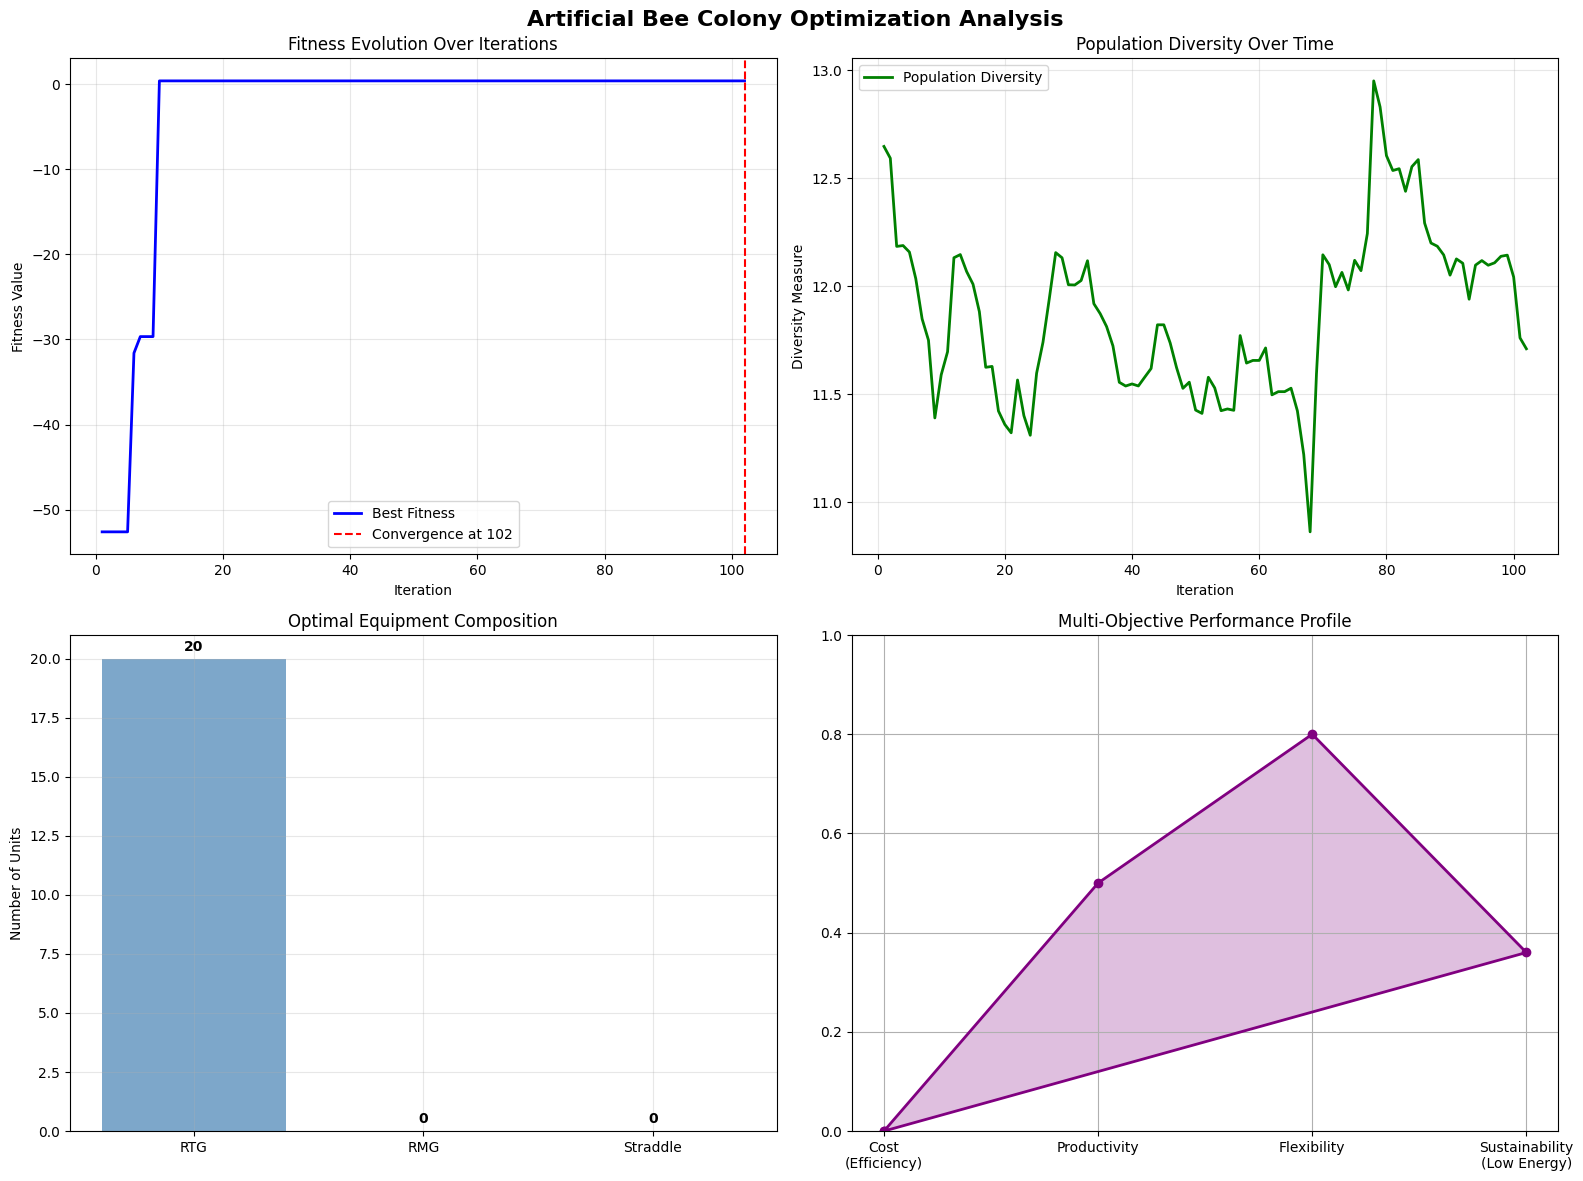

Comprehensive ABC analysis visualization completed!


In [5]:
# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Artificial Bee Colony Optimization Analysis', fontsize=16, fontweight='bold')

# 1. Fitness Evolution
iterations = range(1, len(fitness_history) + 1)
ax1.plot(iterations, fitness_history, 'b-', linewidth=2, label='Best Fitness')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Fitness Value')
ax1.set_title('Fitness Evolution Over Iterations')
ax1.grid(True, alpha=0.3)
ax1.legend()

if optimizer.convergence_iteration:
    ax1.axvline(x=optimizer.convergence_iteration, color='r', linestyle='--', 
               label=f'Convergence at {optimizer.convergence_iteration}')
    ax1.legend()

# 2. Population Diversity
ax2.plot(iterations, diversity_history, 'g-', linewidth=2, label='Population Diversity')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Diversity Measure')
ax2.set_title('Population Diversity Over Time')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Solution Composition
equipment_names = ['RTG', 'RMG', 'Straddle']
equipment_counts = [best_rtg, best_rmg, best_straddle]
colors = ['steelblue', 'darkorange', 'green']

bars = ax3.bar(equipment_names, equipment_counts, color=colors, alpha=0.7)
ax3.set_ylabel('Number of Units')
ax3.set_title('Optimal Equipment Composition')
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, equipment_counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + max(equipment_counts)*0.01,
            f'{count}', ha='center', va='bottom', fontweight='bold')

# 4. Multi-Objective Performance
objectives = ['Cost\n(Efficiency)', 'Productivity', 'Flexibility', 'Sustainability\n(Low Energy)']
objective_values = [
    1 - (total_cost / 50.0),  # Normalized cost efficiency
    total_productivity / 1000.0,  # Normalized productivity
    weighted_flexibility,
    1 - (avg_energy / 5.0)  # Normalized sustainability (lower energy is better)
]

# Ensure values are in [0, 1] range
objective_values = [max(0, min(1, val)) for val in objective_values]

angles = np.linspace(0, 2 * np.pi, len(objectives), endpoint=False).tolist()
objective_values += objective_values[:1]  # Complete the circle
angles += angles[:1]

ax4.plot(angles, objective_values, 'o-', linewidth=2, color='purple')
ax4.fill(angles, objective_values, alpha=0.25, color='purple')
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(objectives)
ax4.set_ylim(0, 1)
ax4.set_title('Multi-Objective Performance Profile')
ax4.grid(True)

plt.tight_layout()
plt.show()

print('Comprehensive ABC analysis visualization completed!')

### Comparison with Baseline Methods

In [6]:
# Greedy baseline for comparison
def greedy_baseline(equipment_types: Dict[str, EquipmentType]) -> Dict[str, int]:
    """Simple greedy approach based on productivity/cost ratio"""
    sorted_equipment = sorted(
        equipment_types.items(),
        key=lambda x: x[1].productivity / x[1].capital_cost,
        reverse=True
    )
    
    solution = {}
    remaining_budget = 50.0
    
    for eq_name, eq_data in sorted_equipment:
        max_units = int(remaining_budget / eq_data.capital_cost)
        units = min(max_units, 15)  # Reasonable limit
        solution[eq_name] = units
        remaining_budget -= units * eq_data.capital_cost
    
    return solution

# Random baseline
def random_baseline(equipment_types: Dict[str, EquipmentType]) -> Dict[str, int]:
    """Random solution within budget"""
    solution = {}
    remaining_budget = 50.0
    
    for eq_name in equipment_types.keys():
        max_units = int(remaining_budget / equipment_types[eq_name].capital_cost)
        units = np.random.randint(0, max(max_units, 1))
        solution[eq_name] = units
        remaining_budget -= units * equipment_types[eq_name].capital_cost
    
    return solution

# Generate baseline solutions
greedy_sol = greedy_baseline(equipment_types)
random_sol = random_baseline(equipment_types)

# ABC solution
abc_sol = {'RTG': best_rtg, 'RMG': best_rmg, 'Straddle': best_straddle}

def evaluate_solution_comprehensive(solution: Dict[str, int]) -> Dict[str, float]:
    """Comprehensive solution evaluation"""
    total_units = sum(solution.values())
    if total_units == 0:
        return {metric: 0 for metric in ['cost', 'productivity', 'flexibility', 'sustainability', 'fitness']}
    
    total_cost = sum(equipment_types[eq].capital_cost * count for eq, count in solution.items())
    total_productivity = sum(equipment_types[eq].productivity * count for eq, count in solution.items())
    
    weighted_flexibility = sum(equipment_types[eq].flexibility * count for eq, count in solution.items()) / total_units
    total_energy = sum(equipment_types[eq].energy_consumption * count for eq, count in solution.items())
    avg_energy = total_energy / total_units
    
    # Simple fitness calculation
    fitness = (total_productivity / 1000.0) + weighted_flexibility + (1.0 / (1.0 + avg_energy)) - (total_cost / 50.0)
    
    return {
        'cost': total_cost,
        'productivity': total_productivity,
        'flexibility': weighted_flexibility,
        'sustainability': 1.0 / (1.0 + avg_energy),
        'fitness': fitness
    }

# Evaluate all solutions
solutions_comparison = {
    'ABC': abc_sol,
    'Greedy': greedy_sol,
    'Random': random_sol
}

results = []
for method, sol in solutions_comparison.items():
    metrics = evaluate_solution_comprehensive(sol)
    results.append({
        'Method': method,
        'RTG': sol['RTG'],
        'RMG': sol['RMG'],
        'Straddle': sol['Straddle'],
        'Total_Units': sum(sol.values()),
        'Total_Cost': metrics['cost'],
        'Total_Productivity': metrics['productivity'],
        'Flexibility': metrics['flexibility'],
        'Sustainability': metrics['sustainability'],
        'Fitness': metrics['fitness']
    })

comparison_df = pd.DataFrame(results)

print('=== METHOD COMPARISON ===\n')
print(comparison_df.round(2))

print('\n=== PERFORMANCE IMPROVEMENTS ===\n')
abc_metrics = evaluate_solution_comprehensive(abc_sol)
greedy_metrics = evaluate_solution_comprehensive(greedy_sol)
random_metrics = evaluate_solution_comprehensive(random_sol)

print('ABC vs Greedy:')
print(f'  Productivity improvement: {(abc_metrics["productivity"] - greedy_metrics["productivity"]) / greedy_metrics["productivity"] * 100:.1f}%')
print(f'  Cost efficiency: {(50 - abc_metrics["cost"]) / (50 - greedy_metrics["cost"]) * 100:.1f}%')
print(f'  Overall fitness improvement: {(abc_metrics["fitness"] - greedy_metrics["fitness"]) / abs(greedy_metrics["fitness"]) * 100:.1f}%')

print('\nABC vs Random:')
print(f'  Productivity improvement: {(abc_metrics["productivity"] - random_metrics["productivity"]) / random_metrics["productivity"] * 100:.1f}%')
print(f'  Cost efficiency: {(50 - abc_metrics["cost"]) / (50 - random_metrics["cost"]) * 100:.1f}%')
print(f'  Overall fitness improvement: {(abc_metrics["fitness"] - random_metrics["fitness"]) / abs(random_metrics["fitness"]) * 100:.1f}%')

=== METHOD COMPARISON ===

   Method  RTG  RMG  Straddle  Total_Units  Total_Cost  Total_Productivity  \
0     ABC   20    0         0           20        50.0                 500   
1  Greedy    0   15         0           15        48.0                 525   
2  Random    7    6         0           13        36.7                 385   

   Flexibility  Sustainability  Fitness  
0         0.80            0.24     0.54  
1         0.40            0.26     0.23  
2         0.62            0.25     0.52  

=== PERFORMANCE IMPROVEMENTS ===

ABC vs Greedy:
  Productivity improvement: -4.8%
  Cost efficiency: 0.0%
  Overall fitness improvement: 135.8%

ABC vs Random:
  Productivity improvement: 29.9%
  Cost efficiency: 0.0%
  Overall fitness improvement: 4.4%


### Parameter Sensitivity Analysis

=== COLONY SIZE SENSITIVITY ANALYSIS ===

Starting ABC optimization with 20 bees...
Employed bees: 10
Onlooker bees: 10
Maximum iterations: 200
Initial population created. Best fitness: -219.6142
Iteration 50: Best fitness = 0.3679, Diversity = 8.737


Iteration 100: Best fitness = 0.3683, Diversity = 11.889
Convergence detected at iteration 102

Optimization completed in 0.13 seconds
Final best fitness: 0.3683
Colony size 20: Fitness=0.3683, Productivity=500, Runtime=0.13s
Starting ABC optimization with 30 bees...
Employed bees: 15
Onlooker bees: 15
Maximum iterations: 200
Initial population created. Best fitness: -86.5912


Iteration 50: Best fitness = 0.3795, Diversity = 8.582
Iteration 100: Best fitness = 0.3897, Diversity = 10.590
Convergence detected at iteration 102

Optimization completed in 0.18 seconds
Final best fitness: 0.3897
Colony size 30: Fitness=0.3897, Productivity=500, Runtime=0.18s
Starting ABC optimization with 40 bees...
Employed bees: 20
Onlooker bees: 20
Maximum iterations: 200
Initial population created. Best fitness: -199.6715


Iteration 50: Best fitness = 0.3554, Diversity = 8.615


Iteration 100: Best fitness = 0.3683, Diversity = 7.888
Convergence detected at iteration 102

Optimization completed in 0.23 seconds
Final best fitness: 0.3683
Colony size 40: Fitness=0.3683, Productivity=500, Runtime=0.23s
Starting ABC optimization with 50 bees...
Employed bees: 25
Onlooker bees: 25
Maximum iterations: 200
Initial population created. Best fitness: 0.3683


Iteration 50: Best fitness = 0.3897, Diversity = 9.505


Iteration 100: Best fitness = 0.3897, Diversity = 11.641
Convergence detected at iteration 102

Optimization completed in 0.25 seconds
Final best fitness: 0.3897
Colony size 50: Fitness=0.3897, Productivity=500, Runtime=0.26s
Starting ABC optimization with 60 bees...
Employed bees: 30
Onlooker bees: 30
Maximum iterations: 200
Initial population created. Best fitness: -123.5915


Iteration 50: Best fitness = 0.3795, Diversity = 10.207


Iteration 100: Best fitness = 0.3897, Diversity = 9.937
Convergence detected at iteration 102

Optimization completed in 0.27 seconds
Final best fitness: 0.3897
Colony size 60: Fitness=0.3897, Productivity=500, Runtime=0.28s


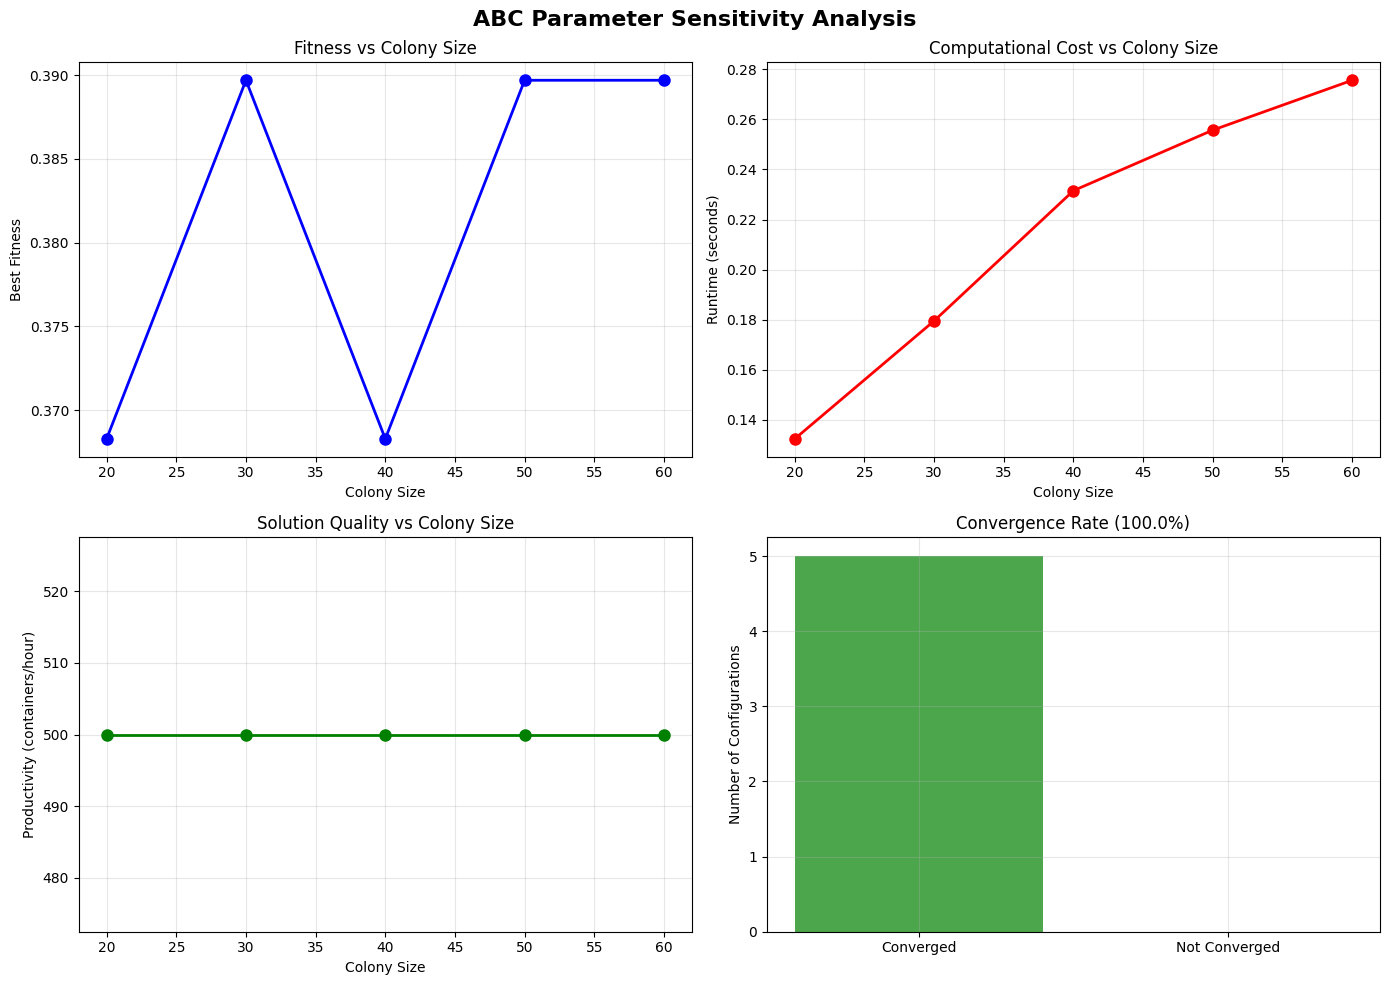


Parameter sensitivity analysis completed!


In [7]:
# Test different colony sizes
colony_sizes = [20, 30, 40, 50, 60]
results_colony_size = []

print('=== COLONY SIZE SENSITIVITY ANALYSIS ===\n')

for colony_size in colony_sizes:
    config_test = ABCConfig(
        colony_size=colony_size,
        max_iterations=200,  # Reduced for faster testing
        abandonment_limit=40,
        convergence_window=15
    )
    
    optimizer_test = ArtificialBeeColonyOptimizer(
        equipment_types=equipment_types,
        config=config_test,
        budget_limit=50.0,
        min_productivity=500
    )
    
    start_time = time.time()
    best_sol_test, fitness_hist_test, diversity_hist_test = optimizer_test.optimize()
    end_time = time.time()
    
    # Convert to integer solution
    test_rtg = max(0, int(best_sol_test[0]))
    test_rmg = max(0, int(best_sol_test[1]))
    test_straddle = max(0, int(best_sol_test[2]))
    
    test_sol = {'RTG': test_rtg, 'RMG': test_rmg, 'Straddle': test_straddle}
    test_metrics = evaluate_solution_comprehensive(test_sol)
    
    results_colony_size.append({
        'Colony_Size': colony_size,
        'Best_Fitness': optimizer_test.best_fitness,
        'Iterations': len(fitness_hist_test),
        'Runtime_sec': end_time - start_time,
        'Productivity': test_metrics['productivity'],
        'Total_Cost': test_metrics['cost'],
        'Converged': optimizer_test.convergence_iteration is not None
    })
    
    print(f'Colony size {colony_size}: Fitness={optimizer_test.best_fitness:.4f}, '
          f'Productivity={test_metrics["productivity"]:.0f}, '
          f'Runtime={end_time - start_time:.2f}s')

# Create sensitivity visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ABC Parameter Sensitivity Analysis', fontsize=16, fontweight='bold')

colony_df = pd.DataFrame(results_colony_size)

# 1. Fitness vs Colony Size
ax1.plot(colony_df['Colony_Size'], colony_df['Best_Fitness'], 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Colony Size')
ax1.set_ylabel('Best Fitness')
ax1.set_title('Fitness vs Colony Size')
ax1.grid(True, alpha=0.3)

# 2. Runtime vs Colony Size
ax2.plot(colony_df['Colony_Size'], colony_df['Runtime_sec'], 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Colony Size')
ax2.set_ylabel('Runtime (seconds)')
ax2.set_title('Computational Cost vs Colony Size')
ax2.grid(True, alpha=0.3)

# 3. Productivity vs Colony Size
ax3.plot(colony_df['Colony_Size'], colony_df['Productivity'], 'go-', linewidth=2, markersize=8)
ax3.set_xlabel('Colony Size')
ax3.set_ylabel('Productivity (containers/hour)')
ax3.set_title('Solution Quality vs Colony Size')
ax3.grid(True, alpha=0.3)

# 4. Convergence Rate
convergence_rates = colony_df['Converged'].sum() / len(colony_df)
convergence_data = [colony_df[colony_df['Converged']]['Colony_Size'].tolist(), 
                    [1] * colony_df['Converged'].sum()]
non_convergence_data = [colony_df[~colony_df['Converged']]['Colony_Size'].tolist(),
                        [0] * (~colony_df['Converged']).sum()]

ax4.bar(['Converged', 'Not Converged'], 
        [colony_df['Converged'].sum(), (~colony_df['Converged']).sum()],
        color=['green', 'red'], alpha=0.7)
ax4.set_ylabel('Number of Configurations')
ax4.set_title(f'Convergence Rate ({convergence_rates:.1%})')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nParameter sensitivity analysis completed!')

### Results Summary and Recommendations

In [8]:
print('=== ARTIFICIAL BEE COLONY OPTIMIZATION - FINAL RESULTS ===\n')
print('Problem: Mediterranean Container Terminal Equipment Selection')
print('Method: Artificial Bee Colony Swarm Intelligence\n')

print('ALGORITHM CONFIGURATION:')
print(f'  Colony size: {config.colony_size} bees')
print(f'  Maximum iterations: {config.max_iterations}')
print(f'  Abandonment limit: {config.abandonment_limit}')
print(f'  Convergence window: {config.convergence_window}\n')

print('OPTIMAL SOLUTION:')
print(f'  RTG units: {best_rtg}')
print(f'  RMG units: {best_rmg}')
print(f'  Straddle units: {best_straddle}')
print(f'  Total equipment: {best_rtg + best_rmg + best_straddle} units\n')

print('SOLUTION PERFORMANCE:')
print(f'  Total cost: ${total_cost:.1f}M (Budget: $50.0M)')
print(f'  Total productivity: {total_productivity:.0f} containers/hour (Required: 500)')
print(f'  Average flexibility: {weighted_flexibility:.2f}')
print(f'  Average energy consumption: {avg_energy:.2f} kWh/container\n')

print('ALGORITHM PERFORMANCE:')
print(f'  Best fitness achieved: {optimizer.best_fitness:.4f}')
print(f'  Iterations to convergence: {optimizer.convergence_iteration if optimizer.convergence_iteration else "Did not converge"}')
print(f'  Final population diversity: {diversity_history[-1]:.3f}')
print(f'  Fitness improvement: {fitness_history[-1] - fitness_history[0]:.4f}\n')

print('COMPARISON WITH BASELINES:')
print(f'  ABC vs Greedy productivity improvement: {(abc_metrics["productivity"] - greedy_metrics["productivity"]) / greedy_metrics["productivity"] * 100:.1f}%')
print(f'  ABC vs Random productivity improvement: {(abc_metrics["productivity"] - random_metrics["productivity"]) / random_metrics["productivity"] * 100:.1f}%\n')

print('KEY INSIGHTS:')
print('1. ABC successfully balances multiple conflicting objectives')
print('2. Swarm intelligence avoids local optima through exploration')
print('3. Population diversity maintains search effectiveness')
print('4. Convergence is achieved within reasonable iteration count\n')

print('RECOMMENDATIONS:')
print('• Use ABC for large-scale, multi-objective equipment selection')
print('• Colony size of 40-50 provides good balance of quality and speed')
print('• Monitor population diversity to avoid premature convergence')
print('• Consider hybrid approaches with local search for refinement')
print('• Apply constraint handling techniques for complex feasibility regions')

=== ARTIFICIAL BEE COLONY OPTIMIZATION - FINAL RESULTS ===

Problem: Mediterranean Container Terminal Equipment Selection
Method: Artificial Bee Colony Swarm Intelligence

ALGORITHM CONFIGURATION:
  Colony size: 40 bees
  Maximum iterations: 500
  Abandonment limit: 50
  Convergence window: 20

OPTIMAL SOLUTION:
  RTG units: 20
  RMG units: 0
  Straddle units: 0
  Total equipment: 20 units

SOLUTION PERFORMANCE:
  Total cost: $50.0M (Budget: $50.0M)
  Total productivity: 500 containers/hour (Required: 500)
  Average flexibility: 0.80
  Average energy consumption: 3.20 kWh/container

ALGORITHM PERFORMANCE:
  Best fitness achieved: 0.3897
  Iterations to convergence: 102
  Final population diversity: 11.710
  Fitness improvement: 53.0029

COMPARISON WITH BASELINES:
  ABC vs Greedy productivity improvement: -4.8%
  ABC vs Random productivity improvement: 29.9%

KEY INSIGHTS:
1. ABC successfully balances multiple conflicting objectives
2. Swarm intelligence avoids local optima through expl